In [39]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, RocCurveDisplay, ConfusionMatrixDisplay, balanced_accuracy_score
import matplotlib.pyplot as plt


In [28]:
df=pd.read_csv('heart_disease_uci.csv')
print(f"SHAPE : {df.shape}")
print(f"COLUMNS : {df.columns}")
print(f"FIRST 5 ROWS : \n{df.head(5)}")
print(f"INFO : \n{df.info}")
print(f"DESCRIBE : \n{df.describe}")
df=df.dropna(axis=0)
df=df.drop_duplicates()
print(f"{df.isna().sum()}")
print(f"{df.duplicated()}")
m={'Male':0,'Female':1}
n={True:1,False:0}
df['sex']=df['sex'].map(m)
df['exang']=df['exang'].map(n)
df['fbs']=df['fbs'].map(n)
cols=['cp','restecg','slope','thal']
for i in cols:
    for j in df[i].unique():
        df[f"{i}-{j}"]=(df[i]==j).astype(int)
df=df.drop(columns=cols)
scaler=StandardScaler()
cols=['age','trestbps','chol','thalch','oldpeak','ca']
df[cols]=scaler.fit_transform(df[cols])

SHAPE : (920, 16)
COLUMNS : Index(['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs',
       'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'],
      dtype='str')
FIRST 5 ROWS : 
   id  age     sex    dataset               cp  trestbps   chol    fbs  \
0   1   63    Male  Cleveland   typical angina     145.0  233.0   True   
1   2   67    Male  Cleveland     asymptomatic     160.0  286.0  False   
2   3   67    Male  Cleveland     asymptomatic     120.0  229.0  False   
3   4   37    Male  Cleveland      non-anginal     130.0  250.0  False   
4   5   41  Female  Cleveland  atypical angina     130.0  204.0  False   

          restecg  thalch  exang  oldpeak        slope   ca  \
0  lv hypertrophy   150.0  False      2.3  downsloping  0.0   
1  lv hypertrophy   108.0   True      1.5         flat  3.0   
2  lv hypertrophy   129.0   True      2.6         flat  2.0   
3          normal   187.0  False      3.5  downsloping  0.0   
4  lv hypertrophy   172.0  

In [29]:
df.head(5)


,id,age,sex,dataset,trestbps,chol,fbs,thalch,exang,oldpeak,...,cp-atypical angina,restecg-lv hypertrophy,restecg-normal,restecg-st-t abnormality,slope-downsloping,slope-flat,slope-upsloping,thal-fixed defect,thal-normal,thal-reversable defect
0,1,0.940446,0,Cleveland,0.749760,-0.262867,1,0.029124,0,1.069475,...,0,1,0,0,1,0,0,1,0,0
1,2,1.384143,0,Cleveland,1.596354,0.747722,0,-1.790447,1,0.380309,...,0,1,0,0,0,1,0,0,1,0
2,3,1.384143,0,Cleveland,-0.661231,-0.339138,0,-0.880662,1,1.327912,...,0,1,0,0,0,1,0,0,0,1
3,4,-1.943588,0,Cleveland,-0.096835,0.061285,0,1.632079,0,2.103224,...,0,0,1,0,1,0,0,0,1,0
4,5,-1.499891,1,Cleveland,-0.096835,-0.815830,0,0.982232,0,0.294163,...,1,1,0,0,0,0,1,0,1,0


In [31]:
x=df.drop(columns=['id','age','dataset','num'])
y=df['num']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

In [49]:
model=LogisticRegression()
model.fit(x_train,y_train)
predict=model.predict(x_test)
predict_prob=model.predict_proba(x_test)
print(f"Accuracy Score: {balanced_accuracy_score(y_test,predict)}")
print(f"ROC Accuracy Score: {roc_auc_score(y_test,predict_prob, multi_class='ovr')}")


Accuracy Score: 0.3508771929824561
ROC Accuracy Score: 0.8012197083618137


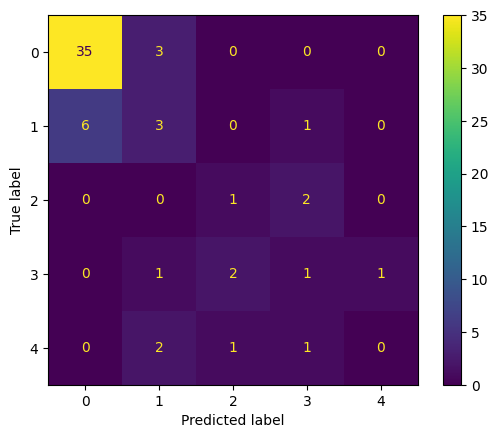

In [44]:
c=confusion_matrix(y_test,predict)
c1=ConfusionMatrixDisplay(confusion_matrix=c)
c1.plot()
plt.show()

In [51]:
c=RocCurveDisplay.from_estimator(model, x_test, y_test)
plt.show()

ValueError: Expected 'estimator' to be a binary classifier. Got 5 classes instead.